<a href="https://colab.research.google.com/github/iiiyahiya111/Machine_Learning/blob/main/fig_mlxtend_support_vector_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machine (SVM) Code and Output :

**`Importing libraries`**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**`Importing dataset`**

In [4]:
dataset = pd.read_csv('Social_Network_Ads.csv')
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

**`Splitting the dataset`**

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [22]:
print(x_train[:5]) # first five entries

[[    44  39000]
 [    32 120000]
 [    38  50000]
 [    32 135000]
 [    52  21000]]


In [21]:
print(y_train[:5]) # first five entries

[0 1 0 1 1]


In [23]:
print(x_test[:5])

[[   30 87000]
 [   38 50000]
 [   35 75000]
 [   30 79000]
 [   35 50000]]


In [9]:
print(y_test)

[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]


**`Feature Scaling`**

In [10]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test)

In [24]:
print(x_train[:5])  # first five entries

[[    44  39000]
 [    32 120000]
 [    38  50000]
 [    32 135000]
 [    52  21000]]


In [25]:
print(x_test[:5])  # first five entries

[[   30 87000]
 [   38 50000]
 [   35 75000]
 [   30 79000]
 [   35 50000]]


**`Train svm model`**

In [13]:
from sklearn.svm import SVC
model = SVC(kernel = 'linear', random_state = 0)
model.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

**`Predicting a singel new result`**

In [14]:
print(model.predict(sc.transform([[30,87000]])))

[0]


**`Predicting the Test set results`**

In [41]:
y_pred = model.predict(X_test)
comarison_predict = np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1)
print(comarison_predict[:10]) # first 10 entries

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]]


**`Confusion Matrix`**

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[66  2]
 [ 8 24]]


0.9

**`Visualize Training set results`**

In [45]:
# to reverse the scaling for visualization
class ScaledModelWrapper:
    def __init__(self, model, scaler):
        self.model = model
        self.scaler = scaler

    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)

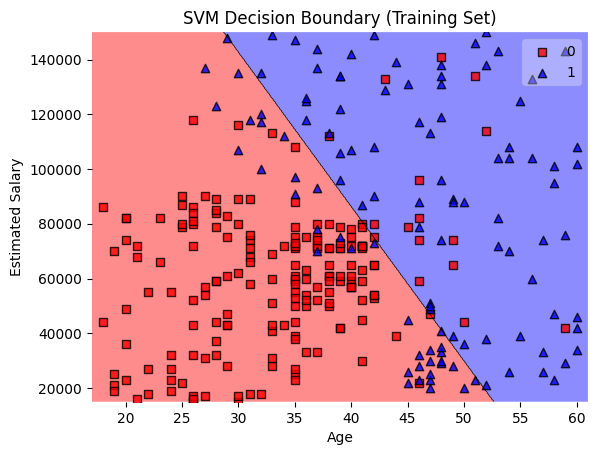

In [46]:
from mlxtend.plotting import plot_decision_regions
X_set = sc.inverse_transform(X_train)
y_set = y_train
wrapped_model = ScaledModelWrapper(model, sc)
plot_decision_regions(X_set, y_set, clf=wrapped_model, colors='red,blue')
plt.title("SVM Decision Boundary (Training Set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()







**`Visualize Test set results`**

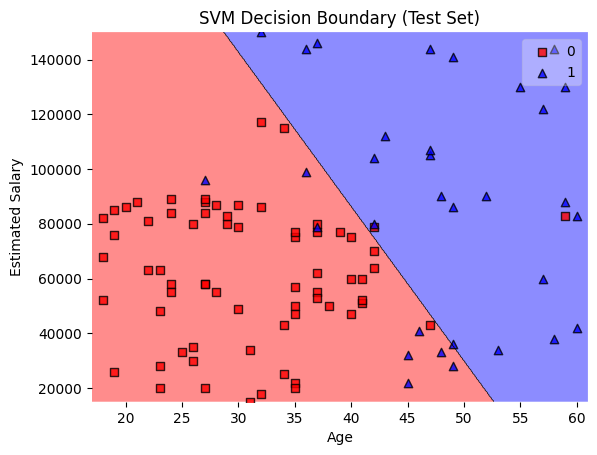

In [47]:
from mlxtend.plotting import plot_decision_regions
X_set = sc.inverse_transform(X_test)
y_set = y_test
wrapped_model = ScaledModelWrapper(model, sc)
plot_decision_regions(X_set, y_set, clf=wrapped_model, colors='red,blue')
plt.title("SVM Decision Boundary (Test Set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()